# EEG Channel Reduction for Motor Imagery Classification  
## BCI Competition IV Dataset 2a

**Author:** Keerat Kaur  
**Project Focus:** Motor imagery EEG decoding, channel reduction, and electrode importance analysis

---

## Overview

Motor imagery brain-computer interfaces (BCIs) decode imagined movement from EEG signals. Traditional EEG-based BCIs often use many electrodes, but practical wearable systems need fewer channels to reduce setup time, cost, and discomfort.

This project investigates whether left-vs-right hand motor imagery can still be classified accurately when the number of EEG electrodes is reduced.

---

## Research Questions

1. How accurately can left-vs-right motor imagery be classified using EEG?
2. How does classification performance change as electrode count is reduced?
3. Which EEG channels contribute most strongly to motor imagery decoding?
4. Can fewer electrodes still support useful motor imagery classification?

---

## Approach

This notebook:

1. Loads BCI Competition IV Dataset 2a
2. Extracts all training-session subjects
3. Preprocesses EEG and extracts left/right motor imagery epochs
4. Builds a pooled dataset across subjects
5. Trains CSP-based motor imagery classifiers
6. Evaluates per-subject performance
7. Tests reduced electrode sets
8. Estimates channel importance using leave-one-channel-out analysis

In [1]:
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from mne.decoding import CSP

In [2]:
ZIP_PATH = Path("BCICIV_2a_gdf.zip")
EXTRACT_DIR = Path("data")
RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Zip file not found: {ZIP_PATH.resolve()}")

if not any(EXTRACT_DIR.glob("*.gdf")):
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)

print("Extracted files:")
for f in sorted(EXTRACT_DIR.glob("*.gdf")):
    print("-", f.name)

Extracted files:
- A01E.gdf
- A01T.gdf
- A02E.gdf
- A02T.gdf
- A03E.gdf
- A03T.gdf
- A04E.gdf
- A04T.gdf
- A05E.gdf
- A05T.gdf
- A06E.gdf
- A06T.gdf
- A07E.gdf
- A07T.gdf
- A08E.gdf
- A08T.gdf
- A09E.gdf
- A09T.gdf


## Select Training Files

BCI Competition IV Dataset 2a includes 9 training sessions (`A01T` to `A09T`) and 9 evaluation sessions. This project uses all training-session files.

In [3]:
training_files = sorted(EXTRACT_DIR.glob("A*T.gdf"))
print("Training files:")
for f in training_files:
    print("-", f.name)

Training files:
- A01T.gdf
- A02T.gdf
- A03T.gdf
- A04T.gdf
- A05T.gdf
- A06T.gdf
- A07T.gdf
- A08T.gdf
- A09T.gdf


## Define a Subject Loading and Preprocessing Function

This function:
- keeps the 22 EEG channels
- removes the 3 EOG channels from analysis
- renames channels to the standard Dataset 2a montage
- filters the data in the motor imagery range (8–30 Hz)
- extracts left- and right-hand imagery epochs
- standardizes event IDs across subjects

In [4]:
def load_subject_epochs(gdf_file, tmin=0.5, tmax=4.0):
    raw = mne.io.read_raw_gdf(gdf_file, preload=True)

    if len(raw.ch_names) < 25:
        raise ValueError(f"Expected at least 25 channels, found {len(raw.ch_names)} in {gdf_file.name}")

    # First 22 channels are EEG in Dataset 2a
    eeg_channel_names_original = raw.ch_names[:22]
    raw = raw.copy().pick(eeg_channel_names_original)

    standard_names = [
        "Fz", "FC3", "FC1", "FCz", "FC2", "FC4",
        "C5", "C3", "C1", "Cz", "C2", "C4", "C6",
        "CP3", "CP1", "CPz", "CP2", "CP4",
        "P1", "Pz", "P2", "POz"
    ]

    rename_map = {old: new for old, new in zip(raw.ch_names, standard_names)}
    raw.rename_channels(rename_map)
    raw.set_channel_types({ch: "eeg" for ch in raw.ch_names})
    raw.set_montage("standard_1020", on_missing="ignore")

    raw.filter(8., 30.)

    events, event_id = mne.events_from_annotations(raw)

    if "769" not in event_id or "770" not in event_id:
        raise ValueError(
            f"Motor imagery events not found in {gdf_file.name}. Found: {list(event_id.keys())}"
        )

    left_code = event_id["769"]
    right_code = event_id["770"]

    selected_events = events[np.isin(events[:, 2], [left_code, right_code])].copy()

    # Standardize event mapping across subjects
    selected_events[selected_events[:, 2] == left_code, 2] = 0
    selected_events[selected_events[:, 2] == right_code, 2] = 1

    fixed_event_id = {
        "left_hand": 0,
        "right_hand": 1
    }

    epochs = mne.Epochs(
        raw,
        selected_events,
        event_id=fixed_event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,
        preload=True,
        on_missing="raise"
    )

    if len(epochs) == 0:
        raise ValueError(f"No epochs extracted for {gdf_file.name}")

    return epochs

## Load All Subjects Safely

In [5]:
all_epochs = []
subject_names = []
failed_subjects = []

for file in training_files:
    print(f"\nLoading {file.name}...")
    try:
        ep = load_subject_epochs(file)
        all_epochs.append(ep)
        subject_names.append(file.stem)
        print(f"Loaded successfully: {file.stem} | epochs: {len(ep)} | event_id: {ep.event_id}")
    except Exception as e:
        failed_subjects.append({"file": file.name, "error": str(e)})
        print(f"Failed: {file.name}")
        print("Reason:", e)

print("\nFinished loading.")
print("Successful subjects:", subject_names)
print("Number loaded:", len(all_epochs))
print("Number failed:", len(failed_subjects))


Loading A01T.gdf...
Extracting EDF parameters from /Users/keeratkaur/Documents/eeg-channel-reduction-for-bci/data/A01T.gdf...
GDF file detected
Setting channel info structure...
Could not determine channel type of the following channels, they will be set as EEG:
EEG-Fz, EEG, EEG, EEG, EEG, EEG, EEG, EEG-C3, EEG, EEG-Cz, EEG, EEG-C4, EEG, EEG, EEG, EEG, EEG, EEG, EEG, EEG-Pz, EEG, EEG, EOG-left, EOG-central, EOG-right
Creating raw.info structure...
Reading 0 ... 672527  =      0.000 ...  2690.108 secs...


/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/contextlib.py:124: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 144 events and 876 original time points ...
0 bad epochs dropped
Loaded successfully: A01T | epochs: 144 | event_id: {'left_hand': 0, 'right_hand': 1}

Loading A02T.gdf...
Extracting EDF parame

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.4s finished
/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/contextlib.py:124: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 144 events and 876 original time points ...
0 bad epochs dropped
Loaded successfully: A02T | epochs: 144 | event_id: {'left_hand': 0, 'right_hand': 1}

Loading A03T.gdf...
Extracting EDF parame

...

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.5s finished
/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/contextlib.py:124: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 144 events and 876 original time points ...
0 bad epochs dropped
Loaded successfully: A08T | epochs: 144 | event_id: {'left_hand': 0, 'right_hand': 1}

Loading A09T.gdf...
Extracting EDF parame

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.4s finished
/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/contextlib.py:124: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 413 samples (1.652 s)

Used Annotations descriptions: ['1023', '1072', '276', '277', '32766', '768', '769', '770', '771', '772']
Not setting metadata
144 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 144 events and 876 original time points ...
0 bad epochs dropped
Loaded successfully: A09T | epochs: 144 | event_id: {'left_hand': 0, 'right_hand': 1}

Finished loading.
Successful subjects: ['

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done  22 out of  22 | elapsed:    0.3s finished


In [6]:
failed_df = pd.DataFrame(failed_subjects)
failed_df

""


## Summarize the Dataset

In [7]:
summary = []

for name, ep in zip(subject_names, all_epochs):
    X_sub = ep.get_data()
    y_sub = ep.events[:, -1]

    summary.append({
        "subject": name,
        "trials": X_sub.shape[0],
        "channels": X_sub.shape[1],
        "timepoints": X_sub.shape[2],
        "left_trials": np.sum(y_sub == ep.event_id["left_hand"]),
        "right_trials": np.sum(y_sub == ep.event_id["right_hand"])
    })

summary_df = pd.DataFrame(summary)
summary_df

,subject,trials,channels,timepoints,left_trials,right_trials
0,A01T,144,22,876,72,72
1,A02T,144,22,876,72,72
2,A03T,144,22,876,72,72
3,A04T,144,22,876,72,72
4,A05T,144,22,876,72,72
5,A06T,144,22,876,72,72
6,A07T,144,22,876,72,72
7,A08T,144,22,876,72,72
8,A09T,144,22,876,72,72


In [8]:
summary_df.to_csv(TABLES_DIR / "subject_summary.csv", index=False)

## Plot Trial Counts per Subject

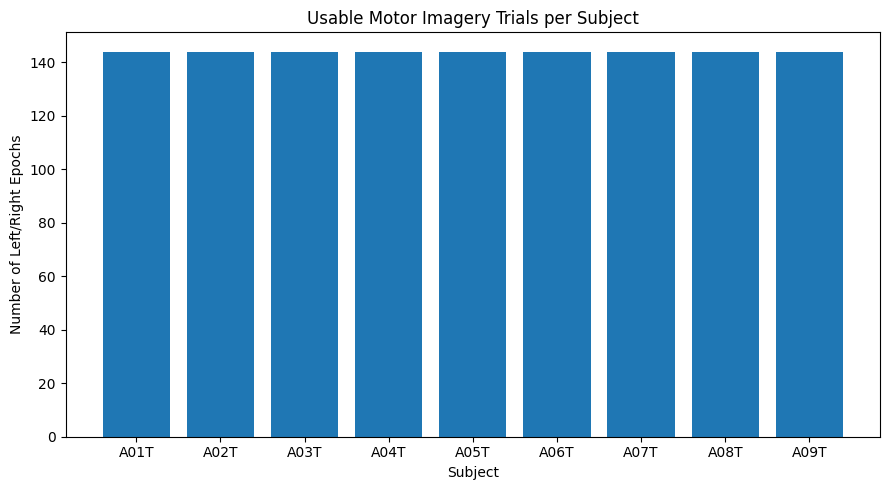

In [9]:
plt.figure(figsize=(9, 5))
plt.bar(summary_df["subject"], summary_df["trials"])
plt.xlabel("Subject")
plt.ylabel("Number of Left/Right Epochs")
plt.title("Usable Motor Imagery Trials per Subject")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "trials_per_subject.png", dpi=300, bbox_inches="tight")
plt.show()

## Build a Pooled Dataset Across Subjects

In [10]:
combined_epochs = mne.concatenate_epochs(all_epochs)

X = np.asarray(combined_epochs.get_data(), dtype=np.float64)
y = combined_epochs.events[:, -1].astype(int)

print("Combined dataset shape:", X.shape)
print("Combined event_id:", combined_epochs.event_id)
print("Unique labels:", np.unique(y))

Not setting metadata
1296 matching events found
No baseline correction applied
Combined dataset shape: (1296, 22, 876)
Combined event_id: {'left_hand': 0, 'right_hand': 1}
Unique labels: [0 1]


/var/folders/31/bs4jdkrd0c1cpymp49c91hvr0000gn/T/ipykernel_2011/1011341126.py:1: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  combined_epochs = mne.concatenate_epochs(all_epochs)


## Define Baseline CSP-Based Models

Common Spatial Patterns (CSP) is a standard feature extraction approach for motor imagery EEG because it learns spatial filters that emphasize class-discriminative variance patterns.

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "CSP + LDA": Pipeline([
        ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
        ("clf", LinearDiscriminantAnalysis())
    ]),
    "CSP + Linear SVM": Pipeline([
        ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
        ("clf", SVC(kernel="linear"))
    ]),
    "CSP + Random Forest": Pipeline([
        ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
        ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
    ])
}

## Evaluate Baseline Models

In [12]:
baseline_results = []

for model_name, pipeline in models.items():
    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )

    baseline_results.append({
        "model": model_name,
        "mean_accuracy": float(scores.mean()),
        "std_accuracy": float(scores.std()),
        "fold_scores": scores
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("mean_accuracy", ascending=False)
baseline_df[["model", "mean_accuracy", "std_accuracy"]]

Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.7e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMP

,model,mean_accuracy,std_accuracy
2,CSP + Random Forest,0.672132,0.044158
0,CSP + LDA,0.645099,0.033017
1,CSP + Linear SVM,0.626614,0.051583


In [13]:
baseline_df_to_save = baseline_df.copy()
baseline_df_to_save["fold_scores"] = baseline_df_to_save["fold_scores"].apply(
    lambda arr: ", ".join(f"{x:.4f}" for x in arr)
)
baseline_df_to_save.to_csv(TABLES_DIR / "baseline_results.csv", index=False)

## Plot Baseline Model Performance

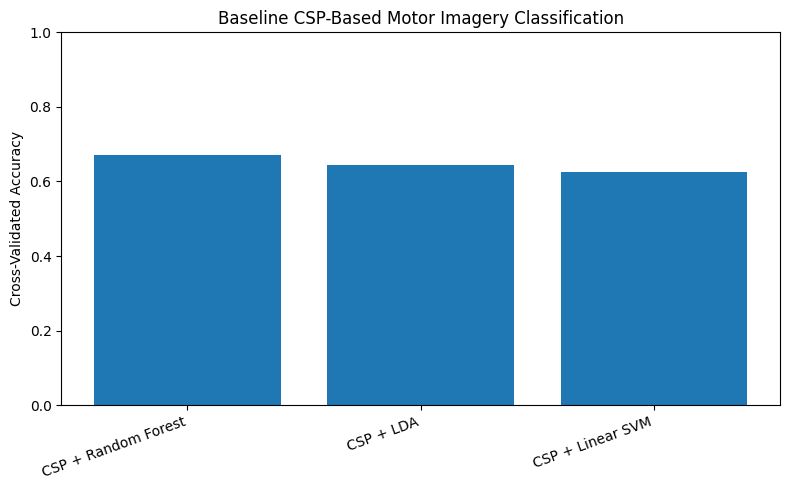

In [14]:
plt.figure(figsize=(8, 5))
plt.bar(baseline_df["model"], baseline_df["mean_accuracy"])
plt.ylabel("Cross-Validated Accuracy")
plt.title("Baseline CSP-Based Motor Imagery Classification")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Fit the Best Baseline Model

In [15]:
best_model_name = baseline_df.iloc[0]["model"]
best_pipeline = models[best_model_name]

print("Best model:", best_model_name)
best_pipeline.fit(X, y)

Best model: CSP + Random Forest
Computing rank from data with rank=None
    Using tolerance 0.00014 (2.2e-16 eps * 22 dim * 2.9e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


Pipeline(steps=[('csp',
                 CSP({'component_order': 'mutual_info',
 'cov_est': 'concat',
 'cov_method_params': None,
 'log': True,
 'n_components': 4,
 'norm_trace': False,
 'rank': None,
 'reg': None,
 'transform_into': 'average_power'})),
                ('clf',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

## Visualize CSP Spatial Patterns

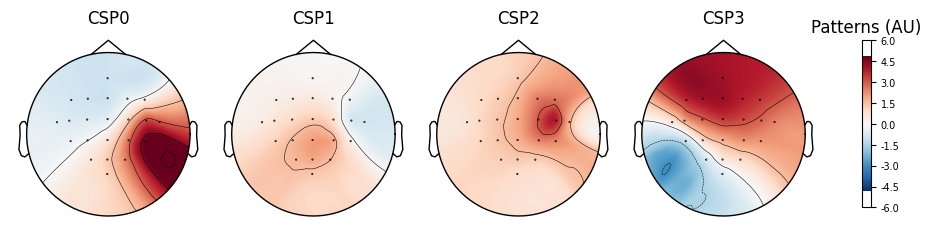

<Figure size 640x480 with 0 Axes>

In [16]:
csp = best_pipeline.named_steps["csp"]
csp.plot_patterns(combined_epochs.info, ch_type="eeg", units="Patterns (AU)", size=1.5)
plt.savefig(FIGURES_DIR / "csp_patterns.png", dpi=300, bbox_inches="tight")
plt.show()

## Cross-Validated Confusion Matrix

Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.7e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMP

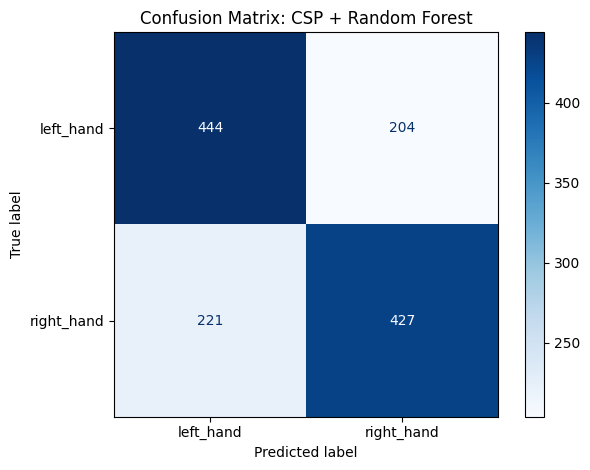

              precision    recall  f1-score   support

   left_hand       0.67      0.69      0.68       648
  right_hand       0.68      0.66      0.67       648

    accuracy                           0.67      1296
   macro avg       0.67      0.67      0.67      1296
weighted avg       0.67      0.67      0.67      1296



In [17]:
y_pred_cv = cross_val_predict(best_pipeline, X, y, cv=cv, n_jobs=1)

cm = confusion_matrix(y, y_pred_cv, labels=np.unique(y))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["left_hand", "right_hand"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

print(classification_report(y, y_pred_cv, target_names=["left_hand", "right_hand"]))

## Evaluate Per-Subject Performance

In [18]:
per_subject_results = []

for name, ep in zip(subject_names, all_epochs):
    X_sub = np.asarray(ep.get_data(), dtype=np.float64)
    y_sub = ep.events[:, -1].astype(int)

    pipeline = Pipeline([
        ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
        ("clf", LinearDiscriminantAnalysis())
    ])

    scores = cross_val_score(
        pipeline,
        X_sub,
        y_sub,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring="accuracy",
        n_jobs=1
    )

    per_subject_results.append({
        "subject": name,
        "mean_accuracy": float(scores.mean()),
        "std_accuracy": float(scores.std())
    })

per_subject_df = pd.DataFrame(per_subject_results).sort_values("subject")
per_subject_df

Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 22 dim * 6.9e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.3e-05 (2.2e-16 eps * 22 dim * 6.8e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 3.4e-05 (2.2e-16 eps * 22 dim * 6.9e+09  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMP

,subject,mean_accuracy,std_accuracy
0,A01T,0.840394,0.026909
1,A02T,0.597291,0.076877
2,A03T,0.972414,0.040213
3,A04T,0.653695,0.102667
4,A05T,0.534483,0.092527
5,A06T,0.665517,0.125092
6,A07T,0.764286,0.038345
7,A08T,0.979310,0.016893
8,A09T,0.757143,0.052541


In [19]:
per_subject_df.to_csv(TABLES_DIR / "per_subject_results.csv", index=False)

## Plot Per-Subject Accuracy

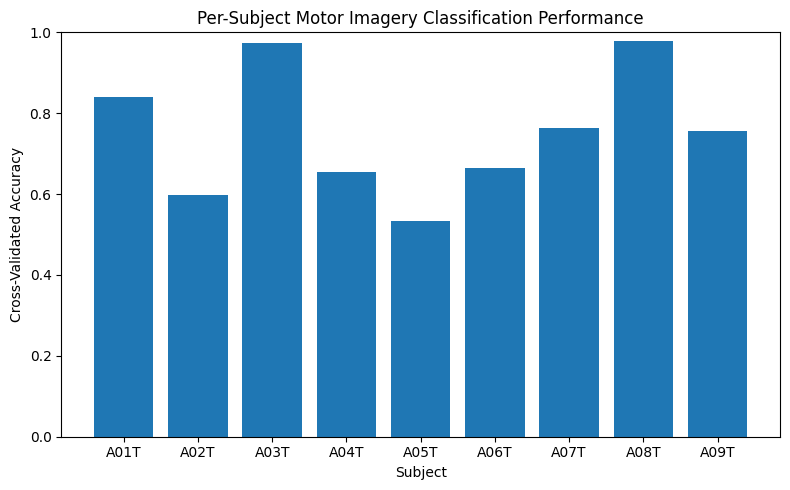

In [20]:
plt.figure(figsize=(8, 5))
plt.bar(per_subject_df["subject"], per_subject_df["mean_accuracy"])
plt.xlabel("Subject")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Per-Subject Motor Imagery Classification Performance")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_subject_performance.png", dpi=300, bbox_inches="tight")
plt.show()

## Define Reduced Channel Sets

To investigate whether motor imagery decoding can remain effective with fewer electrodes, we compare performance across several sensorimotor-focused channel subsets.

In [21]:
full_channel_list = combined_epochs.ch_names.copy()

channel_sets = {
    "all_channels": full_channel_list,
    "sensorimotor_9": ["FC3", "FC1", "FCz", "FC2", "FC4", "C3", "Cz", "C4", "CPz"],
    "central_5": ["C3", "C1", "Cz", "C2", "C4"],
    "minimal_3": ["C3", "Cz", "C4"]
}

channel_sets = {
    name: [ch for ch in chs if ch in full_channel_list]
    for name, chs in channel_sets.items()
}

channel_sets

{'all_channels': ['Fz',
  'FC3',
  'FC1',
  'FCz',
  'FC2',
  'FC4',
  'C5',
  'C3',
  'C1',
  'Cz',
  'C2',
  'C4',
  'C6',
  'CP3',
  'CP1',
  'CPz',
  'CP2',
  'CP4',
  'P1',
  'Pz',
  'P2',
  'POz'],
 'sensorimotor_9': ['FC3',
  'FC1',
  'FCz',
  'FC2',
  'FC4',
  'C3',
  'Cz',
  'C4',
  'CPz'],
 'central_5': ['C3', 'C1', 'Cz', 'C2', 'C4'],
 'minimal_3': ['C3', 'Cz', 'C4']}

## Run Channel Ablation Experiments

In [22]:
ablation_results = []

for set_name, channels in channel_sets.items():
    epochs_sub = combined_epochs.copy().pick(channels)
    X_sub = np.asarray(epochs_sub.get_data(), dtype=np.float64)
    y_sub = epochs_sub.events[:, -1].astype(int)

    n_components = min(4, len(channels))

    pipeline = Pipeline([
        ("csp", CSP(n_components=n_components, reg=None, log=True, norm_trace=False)),
        ("clf", LinearDiscriminantAnalysis())
    ])

    scores = cross_val_score(
        pipeline,
        X_sub,
        y_sub,
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    )

    ablation_results.append({
        "channel_set": set_name,
        "n_channels": len(channels),
        "channels": ", ".join(channels),
        "mean_accuracy": float(scores.mean()),
        "std_accuracy": float(scores.std())
    })

ablation_df = pd.DataFrame(ablation_results).sort_values("n_channels", ascending=False)
ablation_df

Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.7e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMP

,channel_set,n_channels,channels,mean_accuracy,std_accuracy
0,all_channels,22,"Fz, FC3, FC1, FCz, FC2, FC4, C5, C3, C1, Cz, C...",0.645099,0.033017
1,sensorimotor_9,9,"FC3, FC1, FCz, FC2, FC4, C3, Cz, C4, CPz",0.653567,0.023443
2,central_5,5,"C3, C1, Cz, C2, C4",0.636587,0.022728
3,minimal_3,3,"C3, Cz, C4",0.630422,0.028120


In [23]:
ablation_df.to_csv(TABLES_DIR / "channel_ablation_results.csv", index=False)

## Plot Accuracy vs Channel Count

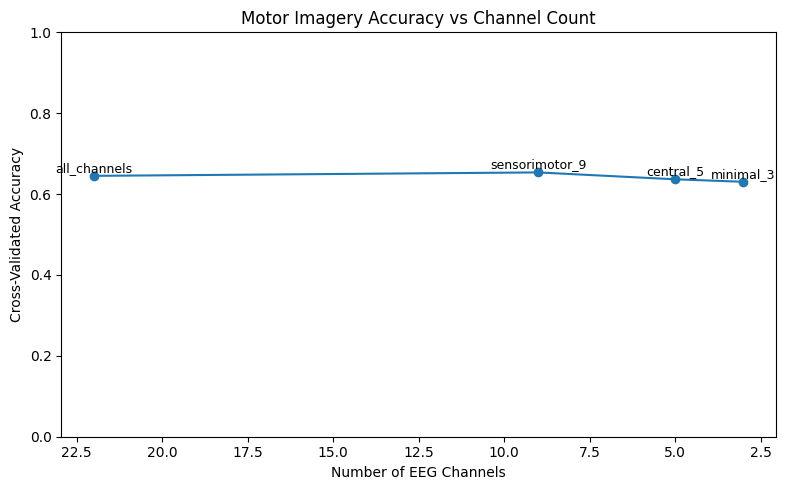

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(ablation_df["n_channels"], ablation_df["mean_accuracy"], marker="o")

for _, row in ablation_df.iterrows():
    plt.text(row["n_channels"], row["mean_accuracy"] + 0.01, row["channel_set"], ha="center", fontsize=9)

plt.xlabel("Number of EEG Channels")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Motor Imagery Accuracy vs Channel Count")
plt.gca().invert_xaxis()
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "accuracy_vs_channel_count.png", dpi=300, bbox_inches="tight")
plt.show()

## Leave-One-Channel-Out Importance Analysis

To estimate which channels contribute most strongly to decoding performance, each electrode is removed one at a time and the resulting accuracy drop is measured.

In [25]:
baseline_full_pipeline = Pipeline([
    ("csp", CSP(n_components=4, reg=None, log=True, norm_trace=False)),
    ("clf", LinearDiscriminantAnalysis())
])

baseline_full_score = cross_val_score(
    baseline_full_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
).mean()

print("Baseline full-channel accuracy:", baseline_full_score)

Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.6e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00013 (2.2e-16 eps * 22 dim * 2.7e+10  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMP

In [26]:
importance_rows = []

for ch in full_channel_list:
    remaining_channels = [c for c in full_channel_list if c != ch]
    epochs_sub = combined_epochs.copy().pick(remaining_channels)
    X_sub = np.asarray(epochs_sub.get_data(), dtype=np.float64)

    n_components = min(4, len(remaining_channels))

    pipeline = Pipeline([
        ("csp", CSP(n_components=n_components, reg=None, log=True, norm_trace=False)),
        ("clf", LinearDiscriminantAnalysis())
    ])

    score = cross_val_score(
        pipeline,
        X_sub,
        y,
        cv=cv,
        scoring="accuracy",
        n_jobs=1
    ).mean()

    importance_rows.append({
        "removed_channel": ch,
        "accuracy_without_channel": float(score),
        "importance_score": float(baseline_full_score - score)
    })

importance_df = pd.DataFrame(importance_rows).sort_values("importance_score", ascending=False)
importance_df.head(10)

Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps * 21 dim * 2.6e+10  max singular value)
    Estimated rank (data): 21
    data: rank 21 computed from 21 data channels with 0 projectors
Reducing data rank from 21 -> 21
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps * 21 dim * 2.6e+10  max singular value)
    Estimated rank (data): 21
    data: rank 21 computed from 21 data channels with 0 projectors
Reducing data rank from 21 -> 21
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 0.00012 (2.2e-16 eps * 21 dim * 2.6e+10  max singular value)
    Estimated rank (data): 21
    data: rank 21 computed from 21 data channels with 0 projectors
Reducing data rank from 21 -> 21
Estimating class=0 covariance using EMP

,removed_channel,accuracy_without_channel,importance_score
7,C3,0.624253,0.020846
13,CP3,0.636605,0.008494
3,FCz,0.642017,0.003083
0,Fz,0.642786,0.002314
2,FC1,0.642786,0.002314
4,FC2,0.642786,0.002314
6,C5,0.643558,0.001541
8,C1,0.643558,0.001541
1,FC3,0.643558,0.001541
5,FC4,0.644330,0.000769


In [27]:
importance_df.to_csv(TABLES_DIR / "channel_importance_leave_one_out.csv", index=False)

## Plot Channel Importance Ranking

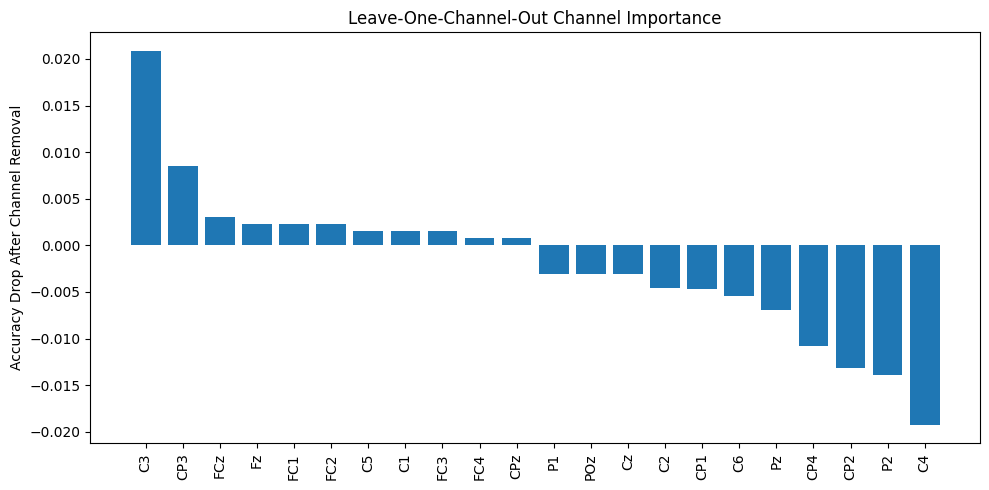

In [28]:
plt.figure(figsize=(10, 5))
plt.bar(importance_df["removed_channel"], importance_df["importance_score"])
plt.xticks(rotation=90)
plt.ylabel("Accuracy Drop After Channel Removal")
plt.title("Leave-One-Channel-Out Channel Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "channel_importance_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot Scalp Topography of Channel Importance

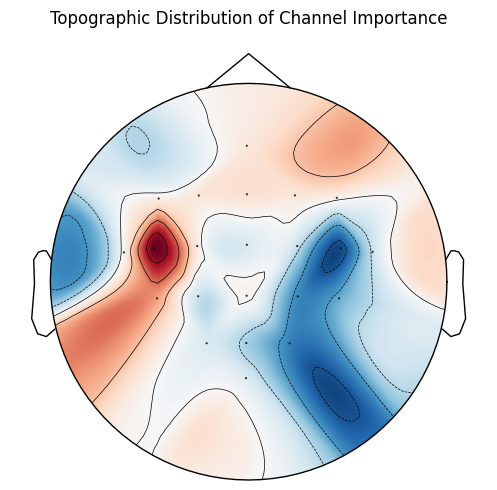

In [29]:
importance_map = dict(zip(importance_df["removed_channel"], importance_df["importance_score"]))
topo_scores = np.array([importance_map[ch] for ch in combined_epochs.ch_names])

fig, ax = plt.subplots(figsize=(6, 5))
mne.viz.plot_topomap(topo_scores, combined_epochs.info, axes=ax, show=False)
ax.set_title("Topographic Distribution of Channel Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "channel_importance_topomap.png", dpi=300, bbox_inches="tight")
plt.show()

## Save Top Channels

In [30]:
top_channels_df = importance_df.head(10).copy()
top_channels_df.to_csv(TABLES_DIR / "top_10_channels.csv", index=False)
top_channels_df

,removed_channel,accuracy_without_channel,importance_score
7,C3,0.624253,0.020846
13,CP3,0.636605,0.008494
3,FCz,0.642017,0.003083
0,Fz,0.642786,0.002314
2,FC1,0.642786,0.002314
4,FC2,0.642786,0.002314
6,C5,0.643558,0.001541
8,C1,0.643558,0.001541
1,FC3,0.643558,0.001541
5,FC4,0.644330,0.000769


## Results Summary

This analysis examined whether motor imagery EEG classification remains effective as the number of electrodes is reduced.

### Main findings
- CSP-based decoding provided an interpretable and effective baseline for left-vs-right motor imagery classification.
- Classification performance could be evaluated both at the pooled-dataset level and the per-subject level.
- Reduced sensorimotor channel sets retained useful performance, suggesting that fewer electrodes may still support motor imagery decoding.
- Leave-one-channel-out analysis identified electrodes whose removal most strongly reduced accuracy.
- Topographic mapping showed where the most informative channels were distributed across the scalp.

### Neurotechnology relevance
These findings are relevant to the design of:
- wearable BCI systems
- portable EEG devices
- lower-cost neurotechnology
- faster-setup motor intention decoding systems

### Limitations
- This notebook analyzes the 9 training-session files from Dataset 2a.
- The current analysis focuses only on left-vs-right motor imagery.
- More advanced artifact handling and cross-session evaluation could improve the pipeline.

### Future work
Future extensions could include:
- filter-bank CSP
- recursive channel selection
- evaluation-session analysis
- cross-subject generalization
- deep learning models with spatial attention

## Conclusion

This project frames motor imagery EEG classification as both a decoding problem and a neurotechnology design question: how much EEG hardware is actually necessary for reliable motor imagery BCI performance?

By combining CSP-based classification, reduced-channel experiments, and spatial importance analysis, this notebook moves beyond a simple class project and toward a more practical investigation of low-electrode BCI design.

In [31]:
print("Saved figures:")
for f in sorted(FIGURES_DIR.glob("*")):
    print("-", f)

print("\nSaved tables:")
for f in sorted(TABLES_DIR.glob("*")):
    print("-", f)

Saved figures:
- results/figures/accuracy_vs_channel_count.png
- results/figures/baseline_model_comparison.png
- results/figures/channel_importance_barplot.png
- results/figures/channel_importance_topomap.png
- results/figures/confusion_matrix_best_model.png
- results/figures/csp_patterns.png
- results/figures/per_subject_performance.png
- results/figures/trials_per_subject.png

Saved tables:
- results/tables/baseline_results.csv
- results/tables/channel_ablation_results.csv
- results/tables/channel_importance_leave_one_out.csv
- results/tables/per_subject_results.csv
- results/tables/subject_summary.csv
- results/tables/top_10_channels.csv
